Natural Language Inferencing (NLI) is a classic NLP (Natural Language Processing) problem that involves taking two sentences (the _premise_ and the _hypothesis_ ), and deciding how they are related- if the premise entails the hypothesis, contradicts it, or neither.

In this tutorial we'll look at the _Contradictory, My Dear Watson_ competition dataset, build a preliminary model using PyTorch, Hugging Face Transformers, and BERT, and prepare a submission file.

This is a local, PyTorch-based adaptation of the original Kaggle TensorFlow/Keras tutorial notebook.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Local run: data files live in the same directory as this notebook
import os
for filename in os.listdir('.'):
    if filename.endswith('.csv'):
        print(filename)

sample_submission.csv
submission.csv
test.csv
train.csv


In [2]:
import truststore
truststore.inject_into_ssl()  # trust the OS cert store (fixes HF Hub downloads behind the corporate proxy)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

C:\Users\alher\Desktop\Watson\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We fix a random seed before any model init / data shuffling. Baseline val_accuracy swung ~1.3 points across identical runs (62.8%–64.0%) purely from `DataLoader` shuffling and the new classifier's random init — fixing the seed removes most of that noise so future A/B comparisons (e.g. regularization, pooling strategy) reflect a real effect rather than a lucky draw. Note this doesn't guarantee bit-exact GPU determinism (cuDNN kernels aren't fully deterministic by default), but it removes the dominant source of variance we were seeing.

In [3]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Let's set up our device (GPU if available, otherwise CPU).

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


The training set contains a premise, a hypothesis, a label (0 = entailment, 1 = neutral, 2 = contradiction), and the language of the text. For more information about what these mean and how the data is structured, check out the data page: https://www.kaggle.com/c/contradictory-my-dear-watson/data

In [5]:
train = pd.read_csv("train.csv")

In [6]:
train.head()

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


Let's look at one of the pairs of sentences.

In [7]:
train.premise.values[1]

'These are issues that we wrestle with in practice groups of law firms, she said. '

In [8]:
train.hypothesis.values[1]

'Practice groups are not permitted to work on these issues.'

In [9]:
train.label.values[1]

2

These statements are contradictory, and the label shows that.

Let's look at the distribution of languages in the training set.

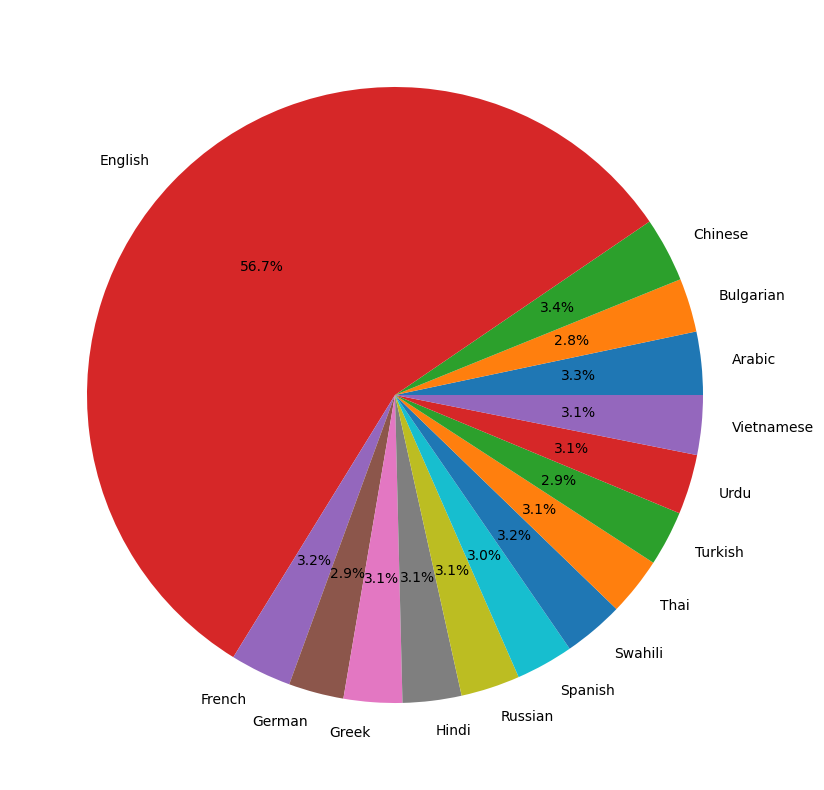

In [10]:
labels, frequencies = np.unique(train.language.values, return_counts = True)

plt.figure(figsize = (10,10))
plt.pie(frequencies,labels = labels, autopct = '%1.1f%%')
plt.show()

## Preparing Data for Input

To start out, we can use a pretrained model. Here, we'll use a multilingual BERT model from huggingface. For more information about BERT, see: https://github.com/google-research/bert/blob/master/multilingual.md

First, we download the tokenizer.

In [11]:
model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

Tokenizers turn sequences of words into arrays of numbers. Let's look at an example:

In [12]:
def encode_sentence(s):
    return tokenizer.encode(s, add_special_tokens=False) + [tokenizer.sep_token_id]

In [13]:
encode_sentence("I love machine learning")

[146, 16138, 21432, 26901, 102]

BERT uses three kind of input data- input word IDs, input masks, and input type IDs.

These allow the model to know that the premise and hypothesis are distinct sentences, and also to ignore any padding from the tokenizer.

We add a [CLS] token to denote the beginning of the inputs, and a [SEP] token to denote the separation between the premise and the hypothesis. We also need to pad all of the inputs to be the same size. For more information about BERT inputs, see: https://huggingface.co/transformers/model_doc/bert.html#bertmodel

Now, we're going to encode all of our premise/hypothesis pairs for input into BERT.

`max_len` was originally 50, but with the mDeBERTa tokenizer that truncates 45.8% of premise+hypothesis pairs (median full length: 48 tokens) — often cutting off the hypothesis entirely, which is half the information the model needs to classify entailment/neutral/contradiction. Raised to 128, which covers 99.4% of examples untruncated. This is a shared preprocessing constant used by both the baseline and mDeBERTa sections, so it's fixed for both to keep the comparison fair.

In [14]:
max_len = 128  # con el tokenizer de mDeBERTa, max_len=50 truncaba el 45.8% de los ejemplos (mediana premise+hypothesis: 48 tokens); 128 cubre el 99.4%

def bert_encode(premises, hypotheses, tokenizer, max_len=max_len):
    encodings = tokenizer(
        list(premises), list(hypotheses),
        padding='max_length', truncation=True, max_length=max_len,
        return_tensors='pt')
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'token_type_ids': encodings['token_type_ids'],
    }

In [15]:
train_input = bert_encode(train.premise.values, train.hypothesis.values, tokenizer)

In [16]:
from sklearn.model_selection import train_test_split

class NLIDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['label'] = self.labels[idx]
        return item

labels = torch.tensor(train.label.values, dtype=torch.long)
train_idx, val_idx = train_test_split(
    np.arange(len(labels)), test_size=0.2, random_state=42)

train_encodings = {k: v[train_idx] for k, v in train_input.items()}
val_encodings = {k: v[val_idx] for k, v in train_input.items()}

train_dataset = NLIDataset(train_encodings, labels[train_idx])
val_dataset = NLIDataset(val_encodings, labels[val_idx])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

## Creating & Training Model

Now, we can incorporate the BERT transformer into a PyTorch model. This model was inspired by the model in this notebook: https://www.kaggle.com/tanulsingh077/deep-learning-for-nlp-zero-to-transformers-bert#BERT-and-Its-Implementation-on-this-Competition, which is a wonderful introduction to NLP!

In [17]:
class NLIModel(nn.Module):
    def __init__(self, model_name, num_labels=3, dropout=0.0, pooling='cls'):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        self.pooling = pooling

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids)
        hidden_states = outputs.last_hidden_state
        if self.pooling == 'mean':
            mask = attention_mask.unsqueeze(-1).type_as(hidden_states)
            pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        else:
            pooled = hidden_states[:, 0, :]
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

In [18]:
model = NLIModel(model_name).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {num_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3980.25it/s]


[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 177,855,747


We also checkpoint the model weights after every epoch — `baseline_last.pt` is overwritten each epoch, while `baseline_best.pt` is only updated when validation loss improves — and apply early stopping if validation loss hasn't improved for 5 consecutive epochs.

In [19]:
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

epochs = 2
patience = 5
best_val_loss = float('inf')
baseline_best_val_accuracy = None
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    baseline_val_accuracy = val_correct / val_total
    avg_val_loss = val_loss / val_total
    print(f'Epoch {epoch+1}/{epochs} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {avg_val_loss:.4f} - val_accuracy: {baseline_val_accuracy:.4f}')

    # Checkpointing: "last" is overwritten every epoch, "best" only when val_loss improves
    torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'baseline_last.pt'))

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        baseline_best_val_accuracy = baseline_val_accuracy
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'baseline_best.pt'))
        print(f'  -> new best val_loss ({best_val_loss:.4f}), saved to baseline_best.pt')
    else:
        epochs_no_improve += 1
        print(f'  -> val_loss did not improve for {epochs_no_improve} epoch(s) (best: {best_val_loss:.4f})')
        if epochs_no_improve >= patience:
            print(f'Early stopping: no val_loss improvement for {patience} consecutive epochs.')
            break

Epoch 1/2 - loss: 0.9433 - accuracy: 0.5416 - val_loss: 0.8110 - val_accuracy: 0.6399


  -> new best val_loss (0.8110), saved to baseline_best.pt


Epoch 2/2 - loss: 0.7196 - accuracy: 0.6903 - val_loss: 0.7991 - val_accuracy: 0.6584


  -> new best val_loss (0.7991), saved to baseline_best.pt


Since this is a 3-class classification problem (entailment / neutral / contradiction), accuracy alone hides *which* classes get confused with each other. We reload the best checkpoint (lowest val_loss, not necessarily the last epoch trained) and plot the confusion matrix on the validation split.

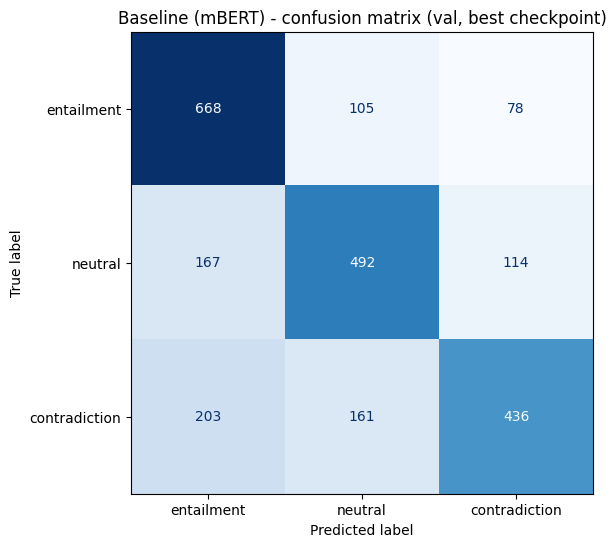

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['entailment', 'neutral', 'contradiction']

model.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'baseline_best.pt')))
model.eval()

val_preds, val_true = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        val_preds.extend(logits.argmax(dim=-1).cpu().tolist())
        val_true.extend(batch_labels.cpu().tolist())

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Baseline (mBERT) - confusion matrix (val, best checkpoint)')
plt.show()

In [21]:
test = pd.read_csv("test.csv")
test_input = bert_encode(test.premise.values, test.hypothesis.values, tokenizer)

In [22]:
test.head()

,id,premise,hypothesis,lang_abv,language
0,c6d58c3f69,بکس، کیسی، راہیل، یسعیاہ، کیلی، کیلی، اور کولم...,"کیسی کے لئے کوئی یادگار نہیں ہوگا, کولمین ہائی...",ur,Urdu
1,cefcc82292,هذا هو ما تم نصحنا به.,عندما يتم إخبارهم بما يجب عليهم فعله ، فشلت ال...,ar,Arabic
2,e98005252c,et cela est en grande partie dû au fait que le...,Les mères se droguent.,fr,French
3,58518c10ba,与城市及其他公民及社区组织代表就IMA的艺术发展进行对话&amp,IMA与其他组织合作，因为它们都依靠共享资金。,zh,Chinese
4,c32b0d16df,Она все еще была там.,"Мы думали, что она ушла, однако, она осталась.",ru,Russian


## Generating & Submitting Predictions

In [23]:
model.eval()
predictions = []
with torch.no_grad():
    for i in range(0, len(test), batch_size):
        input_ids = test_input['input_ids'][i:i+batch_size].to(device)
        attention_mask = test_input['attention_mask'][i:i+batch_size].to(device)
        token_type_ids = test_input['token_type_ids'][i:i+batch_size].to(device)
        logits = model(input_ids, attention_mask, token_type_ids)
        predictions.extend(logits.argmax(dim=-1).cpu().tolist())

The submission file will consist of the ID column and a prediction column. We can just copy the ID column from the test file, make it a dataframe, and then add our prediction column.

In [24]:
submission = test.id.copy().to_frame()
submission['prediction'] = predictions

In [25]:
submission.head()

,id,prediction
0,c6d58c3f69,2
1,cefcc82292,1
2,e98005252c,0
3,58518c10ba,1
4,c32b0d16df,2


In [26]:
submission.to_csv("submission.csv", index = False)

And now we've created our submission file, which can be submitted to the competition. Good luck!

## Mejora: transfer learning desde un modelo preentrenado en NLI (mDeBERTa)

El baseline de arriba parte de `bert-base-multilingual-cased`, preentrenado solo con masked-LM genérico — no sabe nada de NLI de partida, así que tiene que aprender la tarea entera durante el fine-tuning.

Aquí partimos en cambio de [`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`](https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli), que ya está fine-tuneado en MNLI + XNLI (mismo formato premise/hypothesis/entailment-neutral-contradiction que esta competición, en 100 idiomas). Congelamos las capas inferiores del encoder (features lingüísticas más genéricas, ya bien aprendidas) y solo entrenamos las últimas capas más un classifier head nuevo — transfer learning real en vez de fine-tuning completo desde cero.

In [27]:
model_name_nli = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
tokenizer_nli = AutoTokenizer.from_pretrained(model_name_nli)
model_nli = NLIModel(model_name_nli, dropout=0.4, pooling='mean').float().to(device)  # el checkpoint se guardo en fp16; el classifier nuevo es fp32

total_params_nli = sum(p.numel() for p in model_nli.parameters())

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 4448.38it/s]


[transformers] DebertaV2Model LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Congelamos embeddings + capas inferiores del encoder; dejamos entrenables solo las últimas `K` capas del encoder y el classifier head nuevo. El naming de las capas de DeBERTa-v3 (`encoder.layer.{i}.*`) se verificó antes de escribir este filtro.

`K` empezó en 3. Ahora que `max_len=128` arregló el cuello de botella real (el truncamiento), probamos si más capacidad entrenable ayuda: subimos `K` a 6 (la mitad del encoder, 42.5M parámetros entrenables en vez de 21.3M) manteniendo el resto igual para aislar el efecto de este único cambio. Resultado: **el mismo techo exacto de val_accuracy (88.04%)**, pero alcanzado en la época 1 en vez de la 2, con overfitting posterior mucho más agresivo (train_accuracy 97.8% en la época 6) y un coste de entrenamiento mucho mayor (GPU al 100%, VRAM casi al límite, bastante más lento por época). Sin ninguna ganancia a cambio de ese coste, así que volvemos a `K=3`.

In [28]:
K = 3  # nº de capas superiores del encoder que se entrenan (de 12 en total)

for name, param in model_nli.bert.named_parameters():
    if name.startswith('encoder.layer.'):
        layer_idx = int(name.split('.')[2])
        param.requires_grad = layer_idx >= (model_nli.bert.config.num_hidden_layers - K)
    else:
        param.requires_grad = False

for param in model_nli.classifier.parameters():
    param.requires_grad = True

trainable_params_nli = sum(p.numel() for p in model_nli.parameters() if p.requires_grad)
print(f'Parametros entrenables: {trainable_params_nli:,} de {total_params_nli:,} '
      f'({trainable_params_nli/total_params_nli:.1%})')

Parametros entrenables: 21,265,923 de 278,221,059 (7.6%)


Volvemos a tokenizar premise/hypothesis con el tokenizer de mDeBERTa (vocabulario distinto al de mBERT) reutilizando el mismo split train/val (`train_idx`/`val_idx`) que el baseline, para que la comparación de métricas sea justa.

In [29]:
train_input_nli = bert_encode(train.premise.values, train.hypothesis.values, tokenizer_nli)

train_encodings_nli = {k: v[train_idx] for k, v in train_input_nli.items()}
val_encodings_nli = {k: v[val_idx] for k, v in train_input_nli.items()}

train_dataset_nli = NLIDataset(train_encodings_nli, labels[train_idx])
val_dataset_nli = NLIDataset(val_encodings_nli, labels[val_idx])

train_loader_nli = DataLoader(train_dataset_nli, batch_size=batch_size, shuffle=True)
val_loader_nli = DataLoader(val_dataset_nli, batch_size=batch_size)

Entrenamos solo los parámetros no congelados, con warmup + decaimiento lineal del learning rate y gradient clipping — prácticas estándar de fine-tuning de BERT que no estaban en el baseline. Igual que en el baseline, guardamos los pesos en cada epoch (`nli_last.pt` se sobrescribe siempre; `nli_best.pt` solo cuando mejora la val_loss) y aplicamos early stopping si la val_loss no mejora durante 5 epochs consecutivos — con hasta 15 epochs disponibles, esto evita seguir entrenando una vez el modelo converge.

En la primera ejecución se vio overfitting claro: train_accuracy siguió subiendo (hasta ~89%) mientras la val_loss empeoraba a partir de la época 2, así que el early stopping se quedó con esos pesos (~80.4% val_accuracy). Subir la regularización del classifier head (dropout `p=0.2→0.4`, `weight_decay` de 0.01 a 0.1) dio una mejora pequeña y acumulativa (~+0.25 puntos) pero el gap train/val apenas se movió — indicio de que el cuello de botella no está solo en el classifier nuevo, sino en cómo se agrega la representación de la secuencia.

Dos cambios más en esta ejecución: (1) semilla fija (`SEED = 42`, celda al principio del notebook) para que las comparaciones dejen de estar contaminadas por el ~1.3 puntos de ruido que vimos entre runs idénticos del baseline; (2) mean pooling en vez de usar solo el token `[CLS]` — se promedia `last_hidden_state` sobre todos los tokens no-padding (usando `attention_mask`), lo que aprovecha toda la secuencia en vez de un único vector. El baseline no se toca (sigue con `pooling='cls'` por defecto en `NLIModel`).

In [30]:
from transformers import get_linear_schedule_with_warmup

checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

optimizer_nli = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_nli.parameters()), lr=2e-5, weight_decay=0.1)

epochs_nli = 15
patience_nli = 5
total_steps_nli = len(train_loader_nli) * epochs_nli
scheduler_nli = get_linear_schedule_with_warmup(
    optimizer_nli,
    num_warmup_steps=int(0.1 * total_steps_nli),
    num_training_steps=total_steps_nli)

best_val_loss_nli = float('inf')
nli_best_val_accuracy = None
epochs_no_improve_nli = 0

for epoch in range(epochs_nli):
    model_nli.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader_nli:
        optimizer_nli.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_nli.parameters(), max_norm=1.0)
        optimizer_nli.step()
        scheduler_nli.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model_nli.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader_nli:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model_nli(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    nli_val_accuracy = val_correct / val_total
    avg_val_loss_nli = val_loss / val_total
    print(f'Epoch {epoch+1}/{epochs_nli} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {avg_val_loss_nli:.4f} - val_accuracy: {nli_val_accuracy:.4f}')

    # Checkpointing: "last" se sobrescribe cada epoch, "best" solo cuando mejora la val_loss
    torch.save(model_nli.state_dict(), os.path.join(checkpoint_dir, 'nli_last.pt'))

    if avg_val_loss_nli < best_val_loss_nli:
        best_val_loss_nli = avg_val_loss_nli
        nli_best_val_accuracy = nli_val_accuracy
        epochs_no_improve_nli = 0
        torch.save(model_nli.state_dict(), os.path.join(checkpoint_dir, 'nli_best.pt'))
        print(f'  -> nuevo mejor val_loss ({best_val_loss_nli:.4f}), guardado en nli_best.pt')
    else:
        epochs_no_improve_nli += 1
        print(f'  -> val_loss sin mejora desde hace {epochs_no_improve_nli} epoch(s) (mejor: {best_val_loss_nli:.4f})')
        if epochs_no_improve_nli >= patience_nli:
            print(f'Early stopping: sin mejora en val_loss durante {patience_nli} epochs consecutivos.')
            break

Epoch 1/15 - loss: 0.6796 - accuracy: 0.7256 - val_loss: 0.3424 - val_accuracy: 0.8775


  -> nuevo mejor val_loss (0.3424), guardado en nli_best.pt


Epoch 2/15 - loss: 0.3787 - accuracy: 0.8631 - val_loss: 0.3358 - val_accuracy: 0.8804


  -> nuevo mejor val_loss (0.3358), guardado en nli_best.pt


Epoch 3/15 - loss: 0.3261 - accuracy: 0.8823 - val_loss: 0.3414 - val_accuracy: 0.8812


...

  -> val_loss sin mejora desde hace 3 epoch(s) (mejor: 0.3358)


Epoch 6/15 - loss: 0.2281 - accuracy: 0.9180 - val_loss: 0.3908 - val_accuracy: 0.8783


  -> val_loss sin mejora desde hace 4 epoch(s) (mejor: 0.3358)


Epoch 7/15 - loss: 0.2089 - accuracy: 0.9284 - val_loss: 0.4127 - val_accuracy: 0.8738


  -> val_loss sin mejora desde hace 5 epoch(s) (mejor: 0.3358)
Early stopping: sin mejora en val_loss durante 5 epochs consecutivos.


Al ser un problema de clasificación de 3 clases (entailment / neutral / contradiction), la accuracy sola no muestra qué clases se confunden entre sí. Recargamos el checkpoint con mejor val_loss (`nli_best.pt`, no necesariamente el de la última época entrenada) y pintamos la matriz de confusión sobre el split de validación.

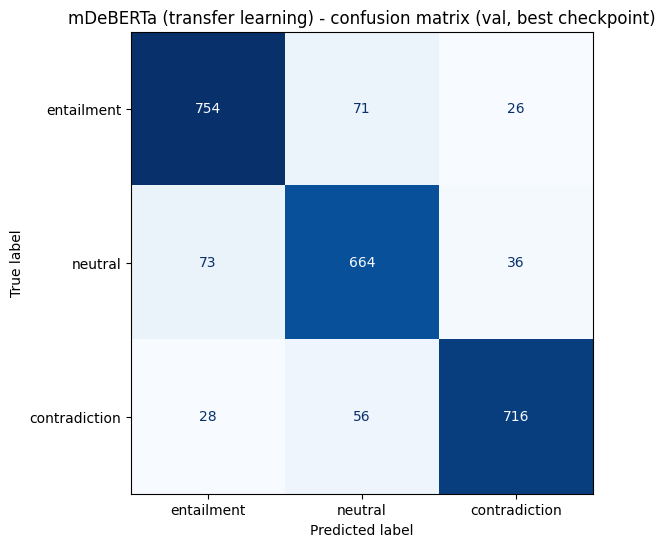

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['entailment', 'neutral', 'contradiction']

model_nli.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'nli_best.pt')))
model_nli.eval()

val_preds_nli, val_true_nli = [], []
with torch.no_grad():
    for batch in val_loader_nli:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli(input_ids, attention_mask, token_type_ids)
        val_preds_nli.extend(logits.argmax(dim=-1).cpu().tolist())
        val_true_nli.extend(batch_labels.cpu().tolist())

cm_nli = confusion_matrix(val_true_nli, val_preds_nli)
disp_nli = ConfusionMatrixDisplay(confusion_matrix=cm_nli, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp_nli.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('mDeBERTa (transfer learning) - confusion matrix (val, best checkpoint)')
plt.show()

Comparación final frente al baseline:

In [32]:
comparison = pd.DataFrame([
    {'modelo': 'bert-base-multilingual-cased (baseline, full fine-tune)', 'val_accuracy': baseline_best_val_accuracy},
    {'modelo': 'mDeBERTa-v3-base-mnli-xnli (transfer learning, freezing)', 'val_accuracy': nli_best_val_accuracy},
])
comparison

,modelo,val_accuracy
0,"bert-base-multilingual-cased (baseline, full f...",0.658416
1,"mDeBERTa-v3-base-mnli-xnli (transfer learning,...",0.880363
